In [2]:
# imports
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
import shap
import sklearn

c:\Users\will6\miniconda3\envs\cs320\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [94]:
#### BASE

#tested various hyperparameters

#read csv
training = pd.read_csv("train_data_m.csv")

#features
features = ['seed_dif', 
            'massey_rank_dif', 
            'avg_margin_dif',
            'avg_eff_A',
            'avg_opp_eff_A', 
            'avg_eff_B', 
            'avg_opp_eff_B',
            'avg_thr_per_A', 
            'ft_per_A', 
            'avg_fg_per_A', 
            'avg_fg_a_per_A',
            'avg_thr_a_per_A', 
            #'avg_to_per_A', 
            'avg_blk_per_A',
            'avg_opp_fg_a_per_A', 
            'avg_opp_fg_per_A', 
            'avg_opp_to_per_A',
            'avg_or_per_A',
            'avg_foul_rec_per_A', 
            'avg_foul_per_A',
            'avg_thr_per_B', 
            'ft_per_B', 
            'avg_fg_per_B', 
            'avg_fg_a_per_B',
            'avg_thr_a_per_B', 
            #'avg_to_per_B', 
            'avg_blk_per_B',
            'avg_opp_fg_a_per_B', 
            'avg_opp_fg_per_B', 
            'avg_opp_to_per_B',
            'avg_or_per_B',
            'avg_foul_rec_per_B', 
            'avg_foul_per_B',
            'thr_a_per_dif', 
            'tempo_pred', 
            'pred_fg_per_dif', 
            'pred_or_per_dif'
            ]


training_dfs = []
val_dfs = []
val_years = []

years = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023,2024]

for i in years:
    if i == 2019:
        val_year = 2021
    else:
        val_year = i+1

    temp_training = training.query("Season <= @i")
    temp_val = training.query("Season == @val_year")

    training_dfs.append(temp_training)
    val_dfs.append(temp_val)
    val_years.append(val_year)

### Model

base_val_error = []

#model
base_mod = XGBClassifier(n_estimators=600, max_depth=3, learning_rate=0.01, subsample = 0.6, colsample_bynode = 0.8, min_split_loss = 12, max_bin = 20, min_child_weight = 2, num_parallel_tree = 1, objective='binary:logistic', seed = 323)

for i in range(len(years)):
    X_train = training_dfs[i][features]
    y_train = training_dfs[i]['result']

    val = val_dfs[i].copy()

    X_val = val[features]
    y_val = val['result']

    #fit model
    base_mod.fit(X_train, y_train)
    
    #make predictions
    preds = base_mod.predict_proba(X_val)

    val['pred'] = preds[:,1]

    val['loss'] = (val['pred'] - val['result'])**2

    print(val_years[i], "Loss:", np.mean(val['loss']))
    base_val_error.append(np.mean(val['loss']))

print(np.mean(base_val_error[-5:]))

#print(val_base.drop('loss', axis = 1).sort_values('pred', ascending = False).head(5))
#val_base.drop('loss', axis = 1).sort_values('pred', ascending = True).head(5)

#shap
explainer = shap.TreeExplainer(base_mod)
shap_values = explainer.shap_values(X_val)
#shap.summary_plot(shap_values, X_val, plot_type="bar", max_display=50)


2012 Loss: 0.1974814012860625
2013 Loss: 0.20004218705746035
2014 Loss: 0.20425875563683518
2015 Loss: 0.17312351795592454
2016 Loss: 0.19560346521596406
2017 Loss: 0.1835725788662484
2018 Loss: 0.202243712122715
2019 Loss: 0.17347296459017142
2021 Loss: 0.22116188201106857
2022 Loss: 0.22264053183889349
2023 Loss: 0.1986697337199703
2024 Loss: 0.19643910984265714
2025 Loss: 0.15934492792347577
0.19965123706721305


In [42]:
### Incremental Learning

#Data

#read csv
training = pd.read_csv("train_data_m.csv")

#features
features = ['seed_dif', 
            'massey_rank_dif', 
            'avg_margin_dif',
            'avg_eff_A',
            'avg_opp_eff_A', 
            'avg_eff_B', 
            'avg_opp_eff_B',
            'avg_thr_per_A', 
            'ft_per_A', 
            'avg_fg_per_A', 
            'avg_fg_a_per_A',
            'avg_thr_a_per_A', 
            'avg_to_per_A', 
            'avg_blk_per_A',
            'avg_opp_fg_a_per_A', 
            'avg_opp_fg_per_A', 
            'avg_opp_to_per_A',
            'avg_or_per_A',
            'avg_foul_rec_per_A', 
            'avg_foul_per_A',
            'avg_thr_per_B', 
            'ft_per_B', 
            'avg_fg_per_B', 
            'avg_fg_a_per_B',
            'avg_thr_a_per_B', 
            'avg_to_per_B', 
            'avg_blk_per_B',
            'avg_opp_fg_a_per_B', 
            'avg_opp_fg_per_B', 
            'avg_opp_to_per_B',
            'avg_or_per_B',
            'avg_foul_rec_per_B', 
            'avg_foul_per_B',
            'thr_a_per_dif', 
            'tempo_pred', 
            'pred_fg_per_dif', 
            'pred_or_per_dif'
            ]

training_dfs = []
val_dfs = []
val_years = []

first_year = 2003
training = training.query("Season >= @first_year").copy()

cutoff_year = 2019

years = [y for y in range(cutoff_year, 2025) if y != 2020]

for i in years:
    if i == 2019:
        val_year = 2021
    else:
        val_year = i+1

    seasons = [i]

    if i == cutoff_year:
        temp_training = training.query("Season <= @i")
    else:
        temp_training = training.query("Season in @seasons")
    
    temp_val = training.query("Season == @val_year")

    training_dfs.append(temp_training)
    val_dfs.append(temp_val)
    val_years.append(val_year)

    # Model

#model
il_mod = XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.01, subsample = 0.6, colsample_bynode = 0.8, max_bin = 20, min_split_loss = 15, min_child_weight = 2, objective='binary:logistic', seed=323)

val_error = []

for i in range(len(years)):
    X_train = training_dfs[i][features]
    y_train = training_dfs[i]['result']

    val = val_dfs[i].copy()

    X_val = val[features]
    y_val = val['result']

    #fit model
    if(i == 0):
        il_mod.fit(X_train, y_train)
    else:
        il_mod.set_params(n_estimators=il_mod.get_booster().num_boosted_rounds() + 50, max_depth = 3, learning_rate = 0.03)
        il_mod.fit(X_train, y_train, xgb_model=il_mod.get_booster()
    )
    
#round(mod.get_booster().num_boosted_rounds()*0.08)

    #make predictions
    preds = il_mod.predict_proba(X_val)

    val['pred'] = preds[:,1]

    val['loss'] = (val['pred'] - val['result'])**2

    val_error.append(np.mean(val['loss']))
    print(val_years[i], "Loss:", np.mean(val['loss']), " |  Dif:", np.mean(val['loss']) - base_val_error[val_years[i] - 2017])


print("Last 5 Loss:", np.mean(val_error[-5:]), " | Dif:", np.mean(val_error[-5:]) - np.mean(base_val_error[-5:]))

#shap
explainer = shap.TreeExplainer(il_mod)
shap_values = explainer.shap_values(X_val)
#shap.summary_plot(shap_values, X_val, plot_type="bar", max_display=50)

2021 Loss: 0.22152399183042915  |  Dif: 0.00036210981936057873
2022 Loss: 0.22184573596660553  |  Dif: -0.0007947958722879511
2023 Loss: 0.20275984988765444  |  Dif: 0.004090116167684149
2024 Loss: 0.1981018661123207  |  Dif: 0.0016627562696635567
2025 Loss: 0.16061264233966124  |  Dif: 0.001267714416185478
Last 5 Loss: 0.20096881722733423  | Dif: 0.001317580160121179


In [36]:
#### Season as Parameter

#read csv
training = pd.read_csv("train_data_m.csv")

#features
features = ['Season',
            'seed_dif', 
            'massey_rank_dif', 
            'avg_margin_dif',
            'avg_eff_A',
            'avg_opp_eff_A', 
            'avg_eff_B', 
            'avg_opp_eff_B',
            'avg_thr_per_A', 
            'ft_per_A', 
            'avg_fg_per_A', 
            'avg_fg_a_per_A',
            'avg_thr_a_per_A', 
            #'avg_to_per_A', 
            'avg_blk_per_A',
            'avg_opp_fg_a_per_A', 
            'avg_opp_fg_per_A', 
            'avg_opp_to_per_A',
            'avg_or_per_A',
            'avg_foul_rec_per_A', 
            'avg_foul_per_A',
            'avg_thr_per_B', 
            'ft_per_B', 
            'avg_fg_per_B', 
            'avg_fg_a_per_B',
            'avg_thr_a_per_B', 
            #'avg_to_per_B', 
            'avg_blk_per_B',
            'avg_opp_fg_a_per_B', 
            'avg_opp_fg_per_B', 
            'avg_opp_to_per_B',
            'avg_or_per_B',
            'avg_foul_rec_per_B', 
            'avg_foul_per_B',
            'thr_a_per_dif', 
            'tempo_pred', 
            'pred_fg_per_dif', 
            'pred_or_per_dif'
            ]


training_dfs = []
val_dfs = []
val_years = []

years = [2015,2016,2017,2018,2019,2021,2022,2023,2024]

for i in years:
    if i == 2019:
        val_year = 2021
    else:
        val_year = i+1

    temp_training = training.query("Season <= @i")
    temp_val = training.query("Season == @val_year")

    training_dfs.append(temp_training)
    val_dfs.append(temp_val)
    val_years.append(val_year)

### Model

#model
s_mod = XGBClassifier(n_estimators=600, max_depth=3, learning_rate=0.01, subsample = 0.6, colsample_bynode = 0.8, min_split_loss = 12, max_bin = 20, min_child_weight = 2, objective='binary:logistic', seed = 323)

val_error = []

for i in range(len(years)):
    X_train = training_dfs[i][features]
    y_train = training_dfs[i]['result']

    val = val_dfs[i].copy()

    X_val = val[features]
    y_val = val['result']

    #fit model
    s_mod.fit(X_train, y_train)
    
    #make predictions
    preds = s_mod.predict_proba(X_val)

    val['pred'] = preds[:,1]

    val['loss'] = (val['pred'] - val['result'])**2

    val_error.append(np.mean(val['loss']))
    print(val_years[i], "Loss:", np.mean(val['loss']), " |  Dif:", np.mean(val['loss']) - base_val_error[val_years[i] - 2017])


print("Last 5 Loss:", np.mean(val_error[-5:]), " | Dif:", np.mean(val_error[-5:]) - np.mean(base_val_error[-5:]))

#shap
explainer = shap.TreeExplainer(s_mod)
shap_values = explainer.shap_values(X_val)
#shap.summary_plot(shap_values, X_val, plot_type="bar", max_display=50)


2016 Loss: 0.19532169132289753  |  Dif: 0.03597676339942177
2017 Loss: 0.18283335287613472  |  Dif: -0.012770112339829331
2018 Loss: 0.20229216086061685  |  Dif: 0.01871958199436846
2019 Loss: 0.1735392927531772  |  Dif: -0.028704419369537798
2021 Loss: 0.22123557599426438  |  Dif: 7.36939831958161e-05
2022 Loss: 0.2231876104948596  |  Dif: 0.0005470786559661212
2023 Loss: 0.19949853816667018  |  Dif: 0.0008288044466998878
2024 Loss: 0.19649935718082956  |  Dif: 6.0247338172420006e-05
2025 Loss: 0.1591221886426459  |  Dif: -0.00022273928082985894
Last 5 Loss: 0.19990865409585395  | Dif: 0.000257417028640905


In [91]:
#Rolling

#read csv
training = pd.read_csv("train_data_m.csv")

#features
features = ['seed_dif', 
            'massey_rank_dif', 
            'avg_margin_dif',
            'avg_eff_A',
            'avg_opp_eff_A', 
            'avg_eff_B', 
            'avg_opp_eff_B',
            'avg_thr_per_A', 
            'ft_per_A', 
            'avg_fg_per_A', 
            'avg_fg_a_per_A',
            'avg_thr_a_per_A', 
            #'avg_to_per_A', 
            'avg_blk_per_A',
            'avg_opp_fg_a_per_A', 
            'avg_opp_fg_per_A', 
            'avg_opp_to_per_A',
            'avg_or_per_A',
            'avg_foul_rec_per_A', 
            'avg_foul_per_A',
            'avg_thr_per_B', 
            'ft_per_B', 
            'avg_fg_per_B', 
            'avg_fg_a_per_B',
            'avg_thr_a_per_B', 
            #'avg_to_per_B', 
            'avg_blk_per_B',
            'avg_opp_fg_a_per_B', 
            'avg_opp_fg_per_B', 
            'avg_opp_to_per_B',
            'avg_or_per_B',
            'avg_foul_rec_per_B', 
            'avg_foul_per_B',
            'thr_a_per_dif', 
            'tempo_pred', 
            'pred_fg_per_dif', 
            'pred_or_per_dif'
            ]


training_dfs = []
val_dfs = []
val_years = []

y_count = 8

years = [2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023,2024]

for i in years:
    if i == 2019:
        val_year = 2021
    else:
        val_year = i+1

    if i <= 2019 or i >= 2020 + y_count:
        seasons = [i - k for k in range(8)]
    else:
        seasons = [i - k for k in range(9)]

    temp_training = training.query("Season in @seasons")
    temp_val = training.query("Season == @val_year")

    training_dfs.append(temp_training)
    val_dfs.append(temp_val)
    val_years.append(val_year)

### Model

#model
r_mod = XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.01, subsample = 0.6, colsample_bynode = 0.8, min_split_loss = 4, max_bin = 20, min_child_weight = 4, objective='binary:logistic', seed = 323)

val_error = []

for i in range(len(years)):
    X_train = training_dfs[i][features]
    y_train = training_dfs[i]['result']

    val = val_dfs[i].copy()

    X_val = val[features]
    y_val = val['result']

    #fit model
    r_mod.fit(X_train, y_train)
    
    #make predictions
    preds = r_mod.predict_proba(X_val)

    val['pred'] = preds[:,1]

    val['loss'] = (val['pred'] - val['result'])**2

    val_error.append(np.mean(val['loss']))
    print(val_years[i], "Loss:", np.mean(val['loss']), " |  Dif:", np.mean(val['loss']) - base_val_error[val_years[i] - 2017])

print("Last 5 Loss:", np.mean(val_error[-5:]), " | Dif:", np.mean(val_error[-5:]) - np.mean(base_val_error[-5:]))

#shap
explainer = shap.TreeExplainer(r_mod)
shap_values = explainer.shap_values(X_val)
#shap.summary_plot(shap_values, X_val, plot_type="bar", max_display=50)


2011 Loss: 0.22553568490739476  |  Dif: 0.052998950268743766
2012 Loss: 0.19950623903519016  |  Dif: -0.022285484161286867
2013 Loss: 0.19490476597835282  |  Dif: -0.02788936982495735
2014 Loss: 0.20900683072203602  |  Dif: 0.010520384131046973
2015 Loss: 0.1722514512334501  |  Dif: -0.024299474313543734
2016 Loss: 0.20399947568629492  |  Dif: 0.04476224332505441
2017 Loss: 0.1807728205447766  |  Dif: -0.016708580741285894
2018 Loss: 0.2085208569208964  |  Dif: 0.008478669863436039
2019 Loss: 0.17343607541471237  |  Dif: -0.03082268022212281
2021 Loss: 0.22514173147557184  |  Dif: 0.029538266259607787
2022 Loss: 0.22547828356486055  |  Dif: 0.041905704698612156
2023 Loss: 0.19517543897910183  |  Dif: -0.007068273143613163
2024 Loss: 0.1973936539310386  |  Dif: 0.02392068934086719
2025 Loss: 0.15429998107163542  |  Dif: -0.06686190093943314
Last 5 Loss: 0.19949781780444165  | Dif: -0.0002742748953604712


2012 Loss: 0.1993957849423377  |  Dif: -0.021766097068730866
2013 Loss: 0.1976038274781247  |  Dif: -0.025036704360768797
2014 Loss: 0.20519535744443526  |  Dif: 0.006525623724464968
2015 Loss: 0.17459440854376498  |  Dif: -0.021844701298892155
2016 Loss: 0.19874537580837823  |  Dif: 0.03940044788490246
2017 Loss: 0.18160378505596517  |  Dif: -0.01587761623009734
2018 Loss: 0.20339080020509484  |  Dif: 0.0033486131476344883
2019 Loss: 0.1712323797296404  |  Dif: -0.03302637590719479
2021 Loss: 0.21828364411018925  |  Dif: 0.02268017889422519
2022 Loss: 0.2218742287991676  |  Dif: 0.03830164993291921
2023 Loss: 0.1985804930145373  |  Dif: -0.0036632191081776844
2024 Loss: 0.19768785612013948  |  Dif: 0.024214891529968058
2025 Loss: 0.1595193215233308  |  Dif: -0.06164256048773778
Last 5 Loss: 0.1991891087134729  | Dif: -0.0004621283537401544


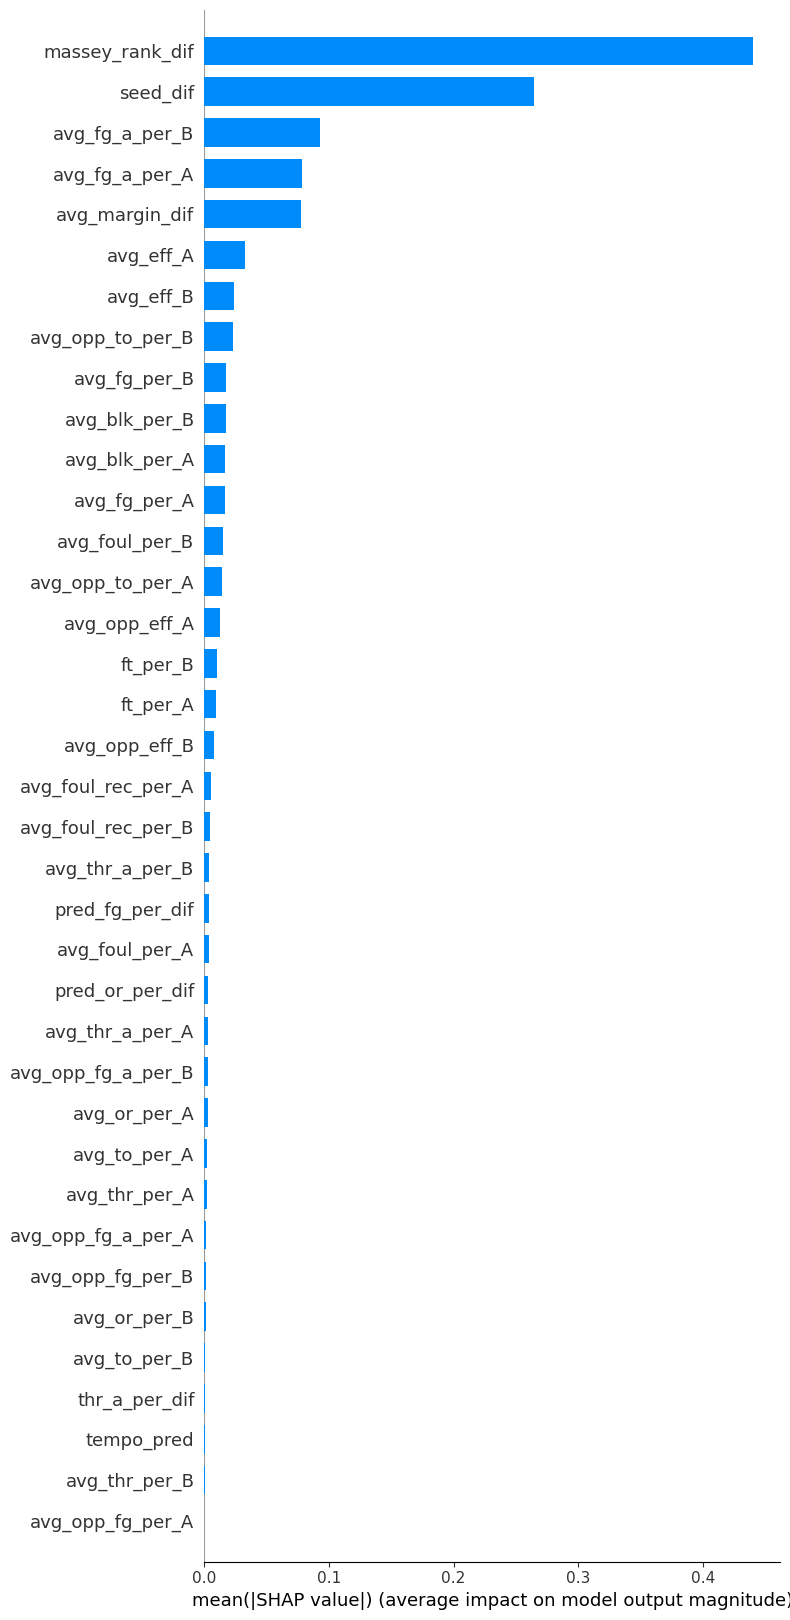

In [ ]:
#### Weights

#read csv
training = pd.read_csv("train_data_m.csv")

#features
features = ['seed_dif', 
            'massey_rank_dif', 
            'avg_margin_dif',
            'avg_eff_A',
            'avg_opp_eff_A', 
            'avg_eff_B', 
            'avg_opp_eff_B',
            'avg_thr_per_A', 
            'ft_per_A', 
            'avg_fg_per_A', 
            'avg_fg_a_per_A',
            'avg_thr_a_per_A', 
            'avg_to_per_A', 
            'avg_blk_per_A',
            'avg_opp_fg_a_per_A', 
            'avg_opp_fg_per_A', 
            'avg_opp_to_per_A',
            'avg_or_per_A',
            'avg_foul_rec_per_A', 
            'avg_foul_per_A',
            'avg_thr_per_B', 
            'ft_per_B', 
            'avg_fg_per_B', 
            'avg_fg_a_per_B',
            'avg_thr_a_per_B', 
            'avg_to_per_B', 
            'avg_blk_per_B',
            'avg_opp_fg_a_per_B', 
            'avg_opp_fg_per_B', 
            'avg_opp_to_per_B',
            'avg_or_per_B',
            'avg_foul_rec_per_B', 
            'avg_foul_per_B',
            'thr_a_per_dif', 
            'tempo_pred', 
            'pred_fg_per_dif', 
            'pred_or_per_dif'
            ]

training_dfs = []
val_dfs = []
val_years = []

weight_param = 0.95

years = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023,2024]

for i in years:
    if i == 2019:
        val_year = 2021
    else:
        val_year = i+1

    temp_training = training.query("Season <= @i")
    temp_val = training.query("Season == @val_year")

    training_dfs.append(temp_training)
    val_dfs.append(temp_val)
    val_years.append(val_year)

### Model

#model
w_mod = XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.01, subsample = 0.6, colsample_bynode = 0.8, min_split_loss = 6, max_bin = 20, min_child_weight = 2, objective='binary:logistic', seed = 323)

val_error = []

for i in range(len(years)):
    temp_df = training_dfs[i]
    temp_df = temp_df.assign(weight = (weight_param ** (temp_df['Season'].max() - temp_df['Season'])).clip(0.1))

    X_train = temp_df[features]
    y_train = temp_df['result']
    train_weights = temp_df['weight']

    val = val_dfs[i].copy()

    X_val = val[features]
    y_val = val['result']

    #fit model
    w_mod.fit(X_train, y_train, sample_weight=train_weights)
    
    #make predictions
    preds = w_mod.predict_proba(X_val)

    val['pred'] = preds[:,1]

    val['loss'] = (val['pred'] - val['result'])**2

    val_error.append(np.mean(val['loss']))
    print(val_years[i], "Loss:", np.mean(val['loss']), " |  Dif:", np.mean(val['loss']) - base_val_error[val_years[i] - 2017])

print("Last 5 Loss:", np.mean(val_error[-5:]), " | Dif:", np.mean(val_error[-5:]) - np.mean(base_val_error[-5:]))

#shap
explainer = shap.TreeExplainer(w_mod)
shap_values = explainer.shap_values(X_val)
#shap.summary_plot(shap_values, X_val, plot_type="bar", max_display=50)
